# 


In [26]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2-4*x+5

In [3]:
f(3.0)

20.0

In [188]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None #function for computing approx deriv
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data: {self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
          self.grad += 1.0 * out.grad
          other.grad += 1.0 * out.grad
        out._backward = _backward
    
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad  += other.data*out.grad
            other.grad += self.data*out.grad
        out._backward = _backward
        return out


    def __pow__(self, other):
        assert isinstance(other, (int, float)), "Only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += other*(self.data**(other-1)) * out.grad
        out.backward = _backward
        return out

    def __rmul__(self, other): #other*self
        return self*other
    
    def __truediv__(self, other):
        return self*(other**-1)

    def __neg__(self):
        return self*-1

    def __sub__(self, other):
        return self + (-other)

    def __radd__(self, other):
        return self+other

    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1-t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data*out.grad
        out._backward = _backward
        return out

    def backward(self):
        #Build topological graph for backprop function call order
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        #Initialize final deriv to be 1 (dF/dF = 1)
        self.grad = 1.0
        #backprop final node upwards
        for node in reversed(topo):
            node._backward()



In [2]:
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out
  
  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out
  
  def __rmul__(self, other): # other * self
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __radd__(self, other): # other + self
    return self + other

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out
  
  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')
    
    def _backward():
      self.grad += out.data * out.grad # NOTE: in the video I incorrectly used = instead of +=. Fixed here.
    out._backward = _backward
    
    return out
  
  
  def backward(self):
    
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

In [3]:
a = Value(2.0)
b = Value(4.0)
a-b
a/b

Value(data=0.5)

In [5]:
a._op

''

In [222]:
a-b

Value(data=-2.0)

In [223]:
a = Value(2.0, label='a')
b = Value(-4.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d=e+c; d.label='d'
f=Value(-2.0, label='f')
L = d*f; L.label='L'
L

Value(data=-4.0)

In [224]:
d._prev

{Value(data=-8.0), Value(data=10.0)}

In [225]:
d._op

'+'

In [226]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid+n._op, label=n._op)
            dot.edge(uid+n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

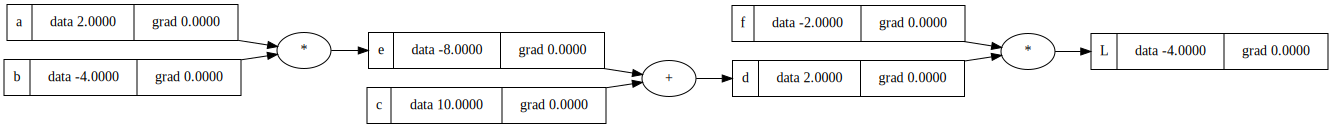

In [227]:
draw_dot(L)

In [228]:
L.grad = 1.0
f.grad = d.data
d.grad = f.data
e.grad = d.grad
c.grad = d.grad
b.grad = a.data*e.grad
a.grad = b.data*e.grad

In [229]:
#one step optimization
a.data += 0.01*a.grad
b.data += 0.01*b.grad
c.data += 0.01*c.grad
d.data += 0.01*d.grad
e.data += 0.01*e.grad
f.data += 0.01*f.grad
e = a*b
d =e+c
L = d*f
print(L.data)

-3.122064000000001


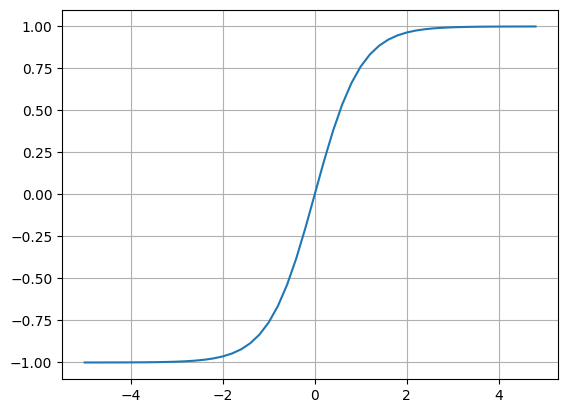

In [230]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid();

In [231]:
#Inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

#Weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias
b = Value(6.881373587, label='b')

#x1*w1 + x2*w2 + b <- 2d Neuron
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label = 'x1w1+x2w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label='o'

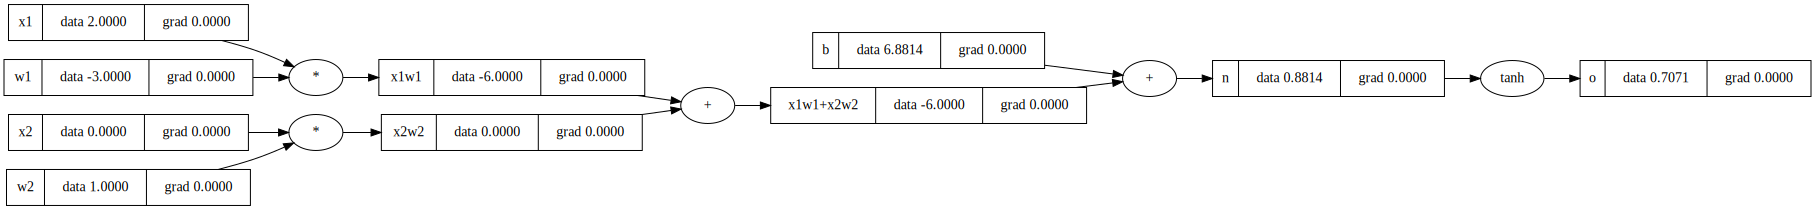

In [232]:
draw_dot(o)

In [233]:
#Use full backprop function:
o.backward()

In [234]:
#Build topological graph for backprop function call order
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
    

In [235]:
o.grad = 1.0
build_topo(o)

for node in reversed(topo):
    node._backward()

In [236]:
# Calling backprop derivatives for each node manually
o.grad = 1.0
o._backward()
n._backward()
b._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

In [237]:
# defining backprop manually
o.grad = 1.0
n.grad = 1-o.data**2
b.grad = n.grad
x1w1x2w2.grad = n.grad
x1w1.grad = x1w1x2w2.grad
x2w2.grad = x1w1x2w2.grad
x2.grad = w2.data*x2w2.grad
w2.grad = x2.data*x2w2.grad
x1.grad = w1.data*x1w1.grad
w1.grad = x1.data*x1w1.grad

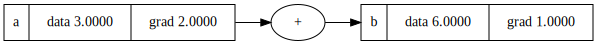

In [238]:
#bug:
a = Value(3.0, label='a')
b = a+a; b.label='b' #issue with 'add' backprop, d(a+a)/da = d(2a)/da = 2, not 1
b.backward()
draw_dot(b)#see also:

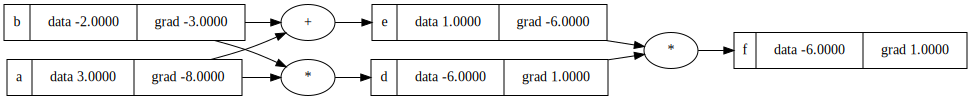

In [239]:
#see also:
a = Value(3.0, label='a')
b = Value(-2.0, label='b')
d = a*b; d.label='d'
e = a+b; e.label='e'
f = d*e; f.label='f'
f.backward()
draw_dot(f)

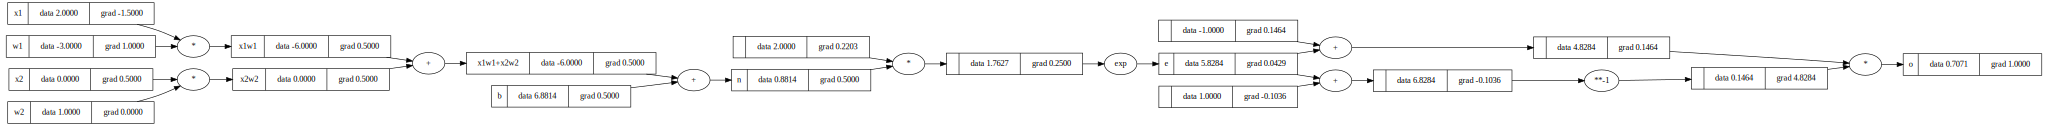

In [240]:
#Inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

#Weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias
b = Value(6.881373587, label='b')

#x1*w1 + x2*w2 + b <- 2d Neuron/Perceptron
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label = 'x1w1+x2w2'
n = x1w1x2w2 + b; n.label = 'n'

#o = n.tanh()
e = (2*n).exp(); e.label='e'
o = (e-1)/(e+1); o.label='o'

o.backward()
draw_dot(o)

In [241]:
#Doing same thing with PyTorch:
import torch

x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True #pytorch defaults leaf nodes don't require gradients
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [362]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x): #called when using notation neuron([val, val, val])
        #w*x+b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        #params = []
        #for neuron in self.neurons:
        #    ps = neuron.parameters()
        #    params.extend(ps)
        #return params

class MLP:

        def __init__(self, nin, nouts):
            sz = [nin] + nouts
            self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

        def __call__(self, x):
            for layer in self.layers:
                x = layer(x)
            return x

        def parameters(self):
            return [p for layer in self.layers for p in layer.parameters()]


In [370]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.17360221656545596)

In [371]:
n.parameters()
len(n.parameters())

41

In [372]:
#Very basic dataset
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [380]:
#forward pass1
for k in range(20):
    #forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    #forgot to zero grad before backward, need to reset all values to zero before next backward
    for p in n.parameters():
        p.grad = 0.0
    #backward pass
    loss.backward()

    #update
    for p in n.parameters():
        p.data += -0.05*p.grad
        

    print(k, loss.data)

0 0.00655752416442677
1 0.006489765462571262
2 0.0064233726898758215
3 0.006358305209616789
4 0.006294523975680146
5 0.006231991455656928
6 0.006170671558351651
7 0.0061105295654108535
8 0.00605153206680198
9 0.005993646899891823
10 0.0059368430918928855
11 0.005881090805462575
12 0.005826361287255713
13 0.005772626819245163
14 0.005719860672638726
15 0.0056680370642320545
16 0.005617131115049077
17 0.005567118811131317
18 0.005517976966346907
19 0.005469683187099644


In [381]:
ypred

[Value(data=0.9724014874031116),
 Value(data=-0.9710760933364734),
 Value(data=-0.9548988991821636),
 Value(data=0.9571362202100888)]